
MPAP MACHINE LEARNING MINI-PROJECT

Loading: C:\Users\HP\OneDrive\Desktop\Miniproject\ML\MPAP_project\MPAP_project\MPAP_Data.csv
Dataset shape: (1101, 37)

------------------------------------------------------------------------
DATA VALIDATION
------------------------------------------------------------------------
Rows: 1101
Columns: 37
Missing values in model data: 0
Unique chemical structures: 233
Target: LogKd

RANDOM RECORD 80/20 SPLIT
Training: Dummy
  R2=-0.0000  RMSE=2.0408  MAE=1.6962
Training: MLR
  R2=0.6768  RMSE=1.1602  MAE=0.8058
Training: Ridge
  R2=0.6747  RMSE=1.1641  MAE=0.8119
Training: RandomForest
  R2=0.8392  RMSE=0.8183  MAE=0.4572
Training: SVM
  R2=0.7953  RMSE=0.9234  MAE=0.5385
Training: XGBoost
  R2=0.8644  RMSE=0.7514  MAE=0.3864

CHEMICAL-STRUCTURE-GROUPED 80/20 SPLIT
Training records: 876
Testing records: 225
Training chemical structures: 186
Testing chemical structures: 47
Chemical overlap: 0
Training: Dummy
  R2=-0.1353  RMSE=1.7069  MAE=1.3890
Traini

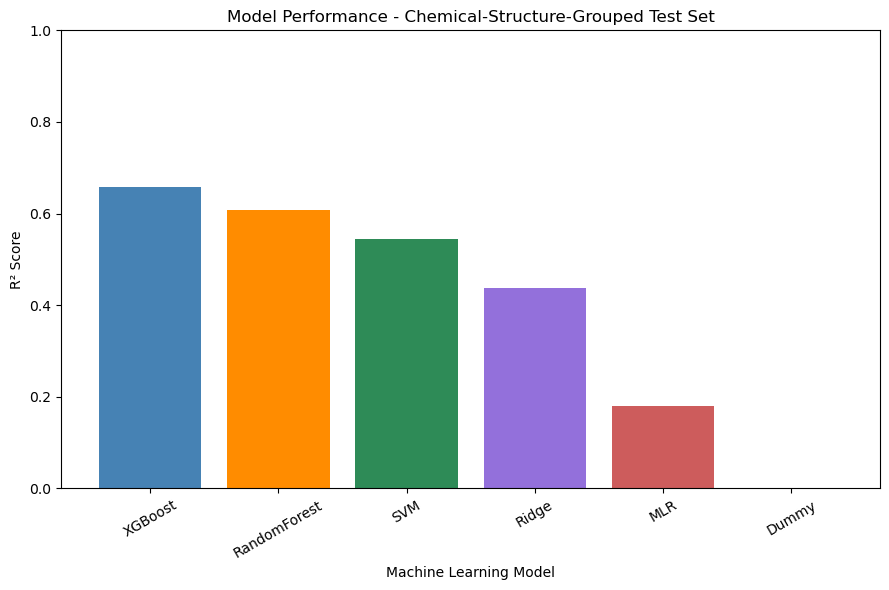

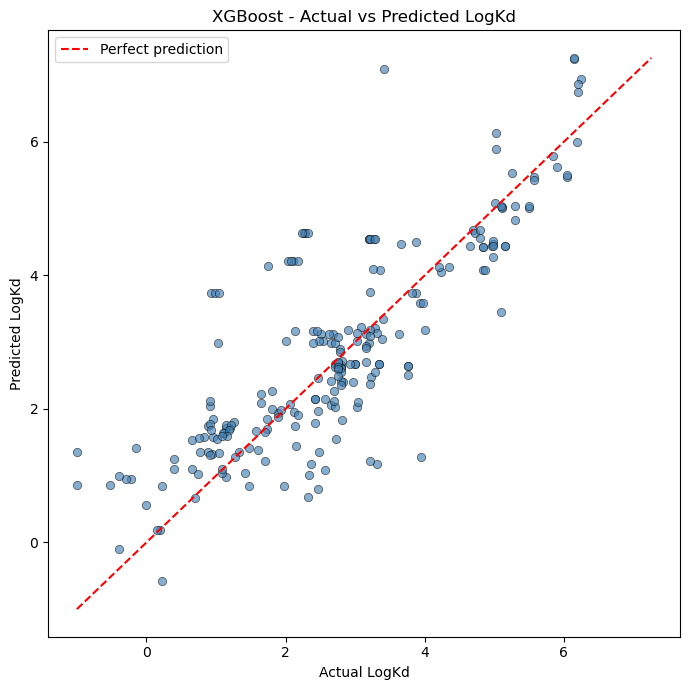

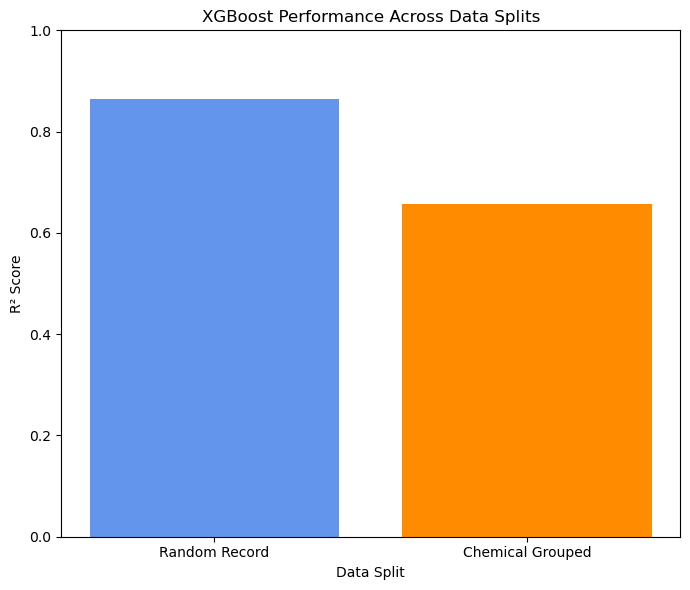

In [ ]:
# ================================================================
# MPAP MACHINE LEARNING MINI-PROJECT
# Predicting pollutant adsorption onto microplastics (LogKd)
#
# Workflow:
#   1. Load and validate curated dataset
#   2. Random-record 80/20 split
#   3. Chemical-structure-grouped 80/20 split
#   4. Random 5-fold cross-validation
#   5. Chemical-grouped 5-fold cross-validation
#   6. Dummy baseline, MLR, Ridge, Random Forest, SVM, XGBoost
#   7. R2, RMSE, MAE
#   8. Feature importance
#   9. SHAP interpretation for the best tree model
#  10. Save predictions, plots, CV results and trained models
# ================================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    KFold,
    GroupKFold,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError("XGBoost is required. Install it with: pip install xgboost") from e

try:
    import shap
except ImportError as e:
    raise ImportError("SHAP is required. Install it with: pip install shap") from e


# ================================================================
# 1. SETTINGS
# ================================================================

DATA_FILE = "C:\\Users\\HP\\OneDrive\\Desktop\\Miniproject\\ML\\MPAP_project\\MPAP_project\\MPAP_Data.csv"
OUTPUT_DIR = "C:\\Users\\HP\\OneDrive\\Desktop\\Miniproject\\ML\\MPAP_Project\\MPAP_project\\MPAP_Results"

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ================================================================
# 2. LOAD DATA
# ================================================================

print("\n" + "=" * 72)
print("MPAP MACHINE LEARNING MINI-PROJECT")
print("=" * 72)
print("\nLoading:", DATA_FILE)

df = pd.read_csv(DATA_FILE)
print("Dataset shape:", df.shape)


# ================================================================
# 3. REQUIRED COLUMNS
# ================================================================

NUMERIC_FEATURES = [
    "MolWt", "MolLogP", "TPSA", "MolMR", "HeavyAtomCount",
    "NumHDonors", "NumHAcceptors", "NumRotatableBonds", "RingCount",
    "NumAromaticRings", "FractionCSP3", "LabuteASA", "NumAliphaticRings",
    "NumSaturatedRings", "NumHeteroatoms", "NumValenceElectrons",
    "BalabanJ", "BertzCT", "Chi0", "Chi1", "Kappa1", "Kappa2", "Kappa3",
    "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge",
    "MinAbsPartialCharge", "Average_size_um"
]

CATEGORICAL_FEATURES = ["Category", "Water_environment"]
TARGET = "LogKd"
GROUP_COLUMN = "Chemical_Group_ID"

REQUIRED = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, GROUP_COLUMN]
missing = [c for c in REQUIRED if c not in df.columns]
if missing:
    raise ValueError("Missing required columns:\n" + "\n".join(missing))


# ================================================================
# 4. VALIDATION
# ================================================================

print("\n" + "-" * 72)
print("DATA VALIDATION")
print("-" * 72)

if df[TARGET].isna().any():
    raise ValueError("LogKd contains missing values.")

if df[GROUP_COLUMN].isna().any():
    raise ValueError("Chemical_Group_ID contains missing values.")

if df["SMILES_canonical"].isna().any():
    raise ValueError("SMILES_canonical contains missing values.")

# Convert numeric predictors to numeric and stop if conversion creates NaNs.
for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

if df[NUMERIC_FEATURES].isna().any().any():
    bad = df[NUMERIC_FEATURES].columns[df[NUMERIC_FEATURES].isna().any()].tolist()
    raise ValueError("Non-numeric/missing values found in numeric columns:\n" + "\n".join(bad))

if df[CATEGORICAL_FEATURES].isna().any().any():
    raise ValueError("Missing values found in categorical predictors.")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values in model data:", int(df[REQUIRED].isna().sum().sum()))
print("Unique chemical structures:", df[GROUP_COLUMN].nunique())
print("Target: LogKd")

summary = pd.DataFrame({
    "Item": [
        "Rows", "Columns", "Unique chemical structures", "Target",
        "LogKd minimum", "LogKd maximum", "LogKd mean", "LogKd SD"
    ],
    "Value": [
        len(df), len(df.columns), df[GROUP_COLUMN].nunique(), TARGET,
        df[TARGET].min(), df[TARGET].max(), df[TARGET].mean(), df[TARGET].std()
    ]
})
summary.to_csv(os.path.join(OUTPUT_DIR, "Dataset_Summary.csv"), index=False)


# ================================================================
# 5. FEATURES / TARGET / GROUPS
# ================================================================

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = df[TARGET].copy()
groups = df[GROUP_COLUMN].copy()


# ================================================================
# 6. PREPROCESSOR
# ================================================================

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), NUMERIC_FEATURES),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", encoder)
    ]), CATEGORICAL_FEATURES)
])


# ================================================================
# 7. MODELS
# ================================================================

models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "MLR": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "SVM": SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.1),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


def make_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])


def metrics(y_true, y_pred):
    return (
        r2_score(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred)
    )


def save_prediction_plot(y_true, y_pred, model_name, split_name):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.65)
    lo = min(float(np.min(y_true)), float(np.min(y_pred)))
    hi = max(float(np.max(y_true)), float(np.max(y_pred)))
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("Actual LogKd")
    plt.ylabel("Predicted LogKd")
    plt.title(f"{model_name} - {split_name}\nActual vs Predicted")
    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"{split_name}_{model_name}_prediction.png"),
        dpi=300
    )
    plt.close()


def save_predictions(indices, y_true, y_pred, model_name, split_name):
    out = pd.DataFrame({
        "Index": indices,
        "Chemical_Group_ID": df.loc[indices, GROUP_COLUMN].values,
        "Actual_LogKd": np.asarray(y_true),
        "Predicted_LogKd": np.asarray(y_pred),
    })
    out["Residual"] = out["Actual_LogKd"] - out["Predicted_LogKd"]
    out.to_csv(
        os.path.join(OUTPUT_DIR, f"{split_name}_{model_name}_predictions.csv"),
        index=False
    )


# ================================================================
# 8. RANDOM RECORD SPLIT
# ================================================================

print("\n" + "=" * 72)
print("RANDOM RECORD 80/20 SPLIT")
print("=" * 72)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

random_results = []
random_models = {}

for name, model in models.items():
    print("Training:", name)
    pipe = make_pipeline(model)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    r2, rmse, mae = metrics(y_test, pred)
    print(f"  R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    random_results.append({"Split": "Random_Record", "Model": name, "R2": r2, "RMSE": rmse, "MAE": mae})
    random_models[name] = pipe
    save_predictions(X_test.index, y_test, pred, name, "Random_Record")
    save_prediction_plot(y_test, pred, name, "Random_Record")
    joblib.dump(pipe, os.path.join(OUTPUT_DIR, f"Random_Record_{name}.joblib"))

random_results = pd.DataFrame(random_results).sort_values("R2", ascending=False)
random_results.to_csv(os.path.join(OUTPUT_DIR, "Random_Record_Results.csv"), index=False)


# ================================================================
# 9. CHEMICAL-GROUPED SPLIT
# ================================================================

print("\n" + "=" * 72)
print("CHEMICAL-STRUCTURE-GROUPED 80/20 SPLIT")
print("=" * 72)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train_g = X.iloc[train_idx]
X_test_g = X.iloc[test_idx]
y_train_g = y.iloc[train_idx]
y_test_g = y.iloc[test_idx]

g_train = groups.iloc[train_idx]
g_test = groups.iloc[test_idx]

overlap = set(g_train) & set(g_test)
if overlap:
    raise RuntimeError("Chemical leakage detected between training and test sets.")

print("Training records:", len(X_train_g))
print("Testing records:", len(X_test_g))
print("Training chemical structures:", g_train.nunique())
print("Testing chemical structures:", g_test.nunique())
print("Chemical overlap:", len(overlap))

assignment = pd.DataFrame({
    "Index": df.index,
    "Chemical_Group_ID": groups.values,
    "Split": "Train"
})
assignment.loc[test_idx, "Split"] = "Test"
assignment.to_csv(os.path.join(OUTPUT_DIR, "Chemical_Grouped_Split.csv"), index=False)

grouped_results = []
grouped_models = {}

for name, model in models.items():
    print("Training:", name)
    pipe = make_pipeline(model)
    pipe.fit(X_train_g, y_train_g)
    pred = pipe.predict(X_test_g)
    r2, rmse, mae = metrics(y_test_g, pred)
    print(f"  R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    grouped_results.append({"Split": "Chemical_Grouped", "Model": name, "R2": r2, "RMSE": rmse, "MAE": mae})
    grouped_models[name] = pipe
    save_predictions(X_test_g.index, y_test_g, pred, name, "Chemical_Grouped")
    save_prediction_plot(y_test_g, pred, name, "Chemical_Grouped")
    joblib.dump(pipe, os.path.join(OUTPUT_DIR, f"Chemical_Grouped_{name}.joblib"))

grouped_results = pd.DataFrame(grouped_results).sort_values("R2", ascending=False)
grouped_results.to_csv(os.path.join(OUTPUT_DIR, "Chemical_Grouped_Results.csv"), index=False)


# ================================================================
# 10. CROSS-VALIDATION
# ================================================================

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}


def run_cv(cv, groups_for_cv=None, label="Random_5Fold"):
    rows = []
    for name, model in models.items():
        pipe = make_pipeline(model)
        kwargs = {"groups": groups_for_cv} if groups_for_cv is not None else {}
        scores = cross_validate(
            pipe, X, y, cv=cv, scoring=scoring, n_jobs=1, **kwargs
        )
        rows.append({
            "CV_Type": label,
            "Model": name,
            "Mean_R2": scores["test_R2"].mean(),
            "SD_R2": scores["test_R2"].std(),
            "Mean_RMSE": (-scores["test_RMSE"]).mean(),
            "SD_RMSE": (-scores["test_RMSE"]).std(),
            "Mean_MAE": (-scores["test_MAE"]).mean(),
            "SD_MAE": (-scores["test_MAE"]).std()
        })
    return pd.DataFrame(rows)

print("\n" + "=" * 72)
print("5-FOLD RANDOM CROSS-VALIDATION")
print("=" * 72)
random_cv = run_cv(
    KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    label="Random_5Fold"
)
random_cv.to_csv(os.path.join(OUTPUT_DIR, "Random_5Fold_CV.csv"), index=False)
print(random_cv.to_string(index=False))

print("\n" + "=" * 72)
print("5-FOLD CHEMICAL-GROUPED CROSS-VALIDATION")
print("=" * 72)
grouped_cv = run_cv(
    GroupKFold(n_splits=N_SPLITS),
    groups_for_cv=groups,
    label="Chemical_Grouped_5Fold"
)
grouped_cv.to_csv(os.path.join(OUTPUT_DIR, "Chemical_Grouped_5Fold_CV.csv"), index=False)
print(grouped_cv.to_string(index=False))


# ================================================================
# 11. FEATURE IMPORTANCE FOR BEST GROUPED TREE MODEL
# ================================================================

best_grouped_row = grouped_results.iloc[0]
best_name = best_grouped_row["Model"]
best_pipe = grouped_models[best_name]

print("\n" + "=" * 72)
print("BEST CHEMICAL-GROUPED TEST MODEL")
print("=" * 72)
print(best_name)
print(f"R2   = {best_grouped_row['R2']:.4f}")
print(f"RMSE = {best_grouped_row['RMSE']:.4f}")
print(f"MAE  = {best_grouped_row['MAE']:.4f}")

joblib.dump(best_pipe, os.path.join(OUTPUT_DIR, "Best_Chemical_Grouped_Model.joblib"))

if best_name in ["RandomForest", "XGBoost"]:
    fitted_preprocessor = best_pipe.named_steps["preprocessor"]
    feature_names = list(fitted_preprocessor.get_feature_names_out())
    importances = best_pipe.named_steps["model"].feature_importances_
    fi = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    fi = fi.sort_values("Importance", ascending=False)
    fi.to_csv(os.path.join(OUTPUT_DIR, f"{best_name}_Feature_Importance.csv"), index=False)

    top = fi.head(20).sort_values("Importance")
    plt.figure(figsize=(8, 7))
    plt.barh(top["Feature"], top["Importance"])
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.title(f"{best_name} - Top 20 Features")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{best_name}_Feature_Importance.png"), dpi=300)
    plt.close()
else:
    print("Best model is not tree-based; tree feature importance is not applicable.")


# ================================================================
# 12. SHAP FOR BEST TREE MODEL
# ================================================================

if best_name in ["RandomForest", "XGBoost"]:
    print("\nRunning SHAP analysis...")
    fitted_preprocessor = best_pipe.named_steps["preprocessor"]
    transformed_test = fitted_preprocessor.transform(X_test_g)
    feature_names = list(fitted_preprocessor.get_feature_names_out())
    transformed_test = pd.DataFrame(transformed_test, columns=feature_names, index=X_test_g.index)

    try:
        explainer = shap.TreeExplainer(best_pipe.named_steps["model"])
        shap_values = explainer.shap_values(transformed_test)
        mean_abs = np.abs(shap_values).mean(axis=0)
        shap_df = pd.DataFrame({
            "Feature": feature_names,
            "Mean_Absolute_SHAP": mean_abs
        }).sort_values("Mean_Absolute_SHAP", ascending=False)
        shap_df.to_csv(os.path.join(OUTPUT_DIR, f"SHAP_{best_name}_Importance.csv"), index=False)

        plt.figure()
        shap.summary_plot(shap_values, transformed_test, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f"SHAP_{best_name}_Summary.png"), dpi=300, bbox_inches="tight")
        plt.close()
        print("SHAP completed successfully.")
    except Exception as e:
        print("SHAP could not be completed:", repr(e))
else:
    print("SHAP skipped because the best model is not tree-based.")


# ================================================================
# 13.GRAPHS 
# ================================================================

print("\n" + "=" * 72)
print("CREATING AND SAVING PROJECT GRAPHS")
print("=" * 72)


# ------------------------------------------------
# GRAPH 1: MODEL PERFORMANCE - CHEMICAL GROUPED
# ------------------------------------------------

models_plot = grouped_results["Model"]
r2_plot = grouped_results["R2"]

plt.figure(figsize=(9, 6))

plt.bar(
    models_plot,
    r2_plot,
    color=[
        "steelblue",
        "darkorange",
        "seagreen",
        "mediumpurple",
        "indianred",
        "saddlebrown"
    ]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.title(
    "Model Performance - Chemical-Structure-Grouped Test Set"
)

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Graph_1_Model_Performance_Grouped.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

# SHOW IN JUPYTER
plt.show()

# Close AFTER showing
plt.close()


# ------------------------------------------------
# GRAPH 2: ACTUAL VS PREDICTED LOGKD - XGBOOST
# ------------------------------------------------

xgb_grouped = grouped_models["XGBoost"]

xgb_pred = xgb_grouped.predict(X_test_g)

actual = np.asarray(y_test_g)
predicted = np.asarray(xgb_pred)

plt.figure(figsize=(7, 7))

plt.scatter(
    actual,
    predicted,
    color="steelblue",
    alpha=0.65,
    edgecolor="black",
    linewidth=0.5
)

minimum = min(
    actual.min(),
    predicted.min()
)

maximum = max(
    actual.max(),
    predicted.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction"
)

plt.legend()

plt.xlabel("Actual LogKd")
plt.ylabel("Predicted LogKd")
plt.title("XGBoost - Actual vs Predicted LogKd")

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Graph_2_XGBoost_Actual_vs_Predicted.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

# SHOW IN JUPYTER
plt.show()

plt.close()


# ------------------------------------------------
# GRAPH 3: RANDOM VS CHEMICAL-GROUPED XGBOOST
# ------------------------------------------------

random_xgb = random_results[
    random_results["Model"] == "XGBoost"
]["R2"].iloc[0]

grouped_xgb = grouped_results[
    grouped_results["Model"] == "XGBoost"
]["R2"].iloc[0]

split_names = [
    "Random Record",
    "Chemical Grouped"
]

split_r2 = [
    random_xgb,
    grouped_xgb
]

plt.figure(figsize=(7, 6))

plt.bar(
    split_names,
    split_r2,
    color=[
        "cornflowerblue",
        "darkorange"
    ]
)

plt.xlabel("Data Split")
plt.ylabel("R² Score")
plt.title("XGBoost Performance Across Data Splits")

plt.ylim(0, 1)

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Graph_3_XGBoost_Split_Comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

# SHOW IN JUPYTER
plt.show()

plt.close()


# ------------------------------------------------
# GRAPH 4: CHEMICAL-GROUPED 5-FOLD CV
# ------------------------------------------------

cv_models = grouped_cv["Model"]
cv_r2 = grouped_cv["Mean_R2"]

plt.figure(figsize=(9, 6))

plt.bar(
    cv_models,
    cv_r2,
    color=[
        "steelblue",
        "darkorange",
        "seagreen",
        "mediumpurple",
        "indianred",
        "saddlebrown"
    ]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Mean R²")
plt.title(
    "Chemical-Grouped 5-Fold Cross-Validation"
)

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Graph_4_Chemical_Grouped_CV.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

# SHOW IN JUPYTER
plt.show()

plt.close()


# ------------------------------------------------
# GRAPH 5: XGBOOST RESIDUAL PLOT
# ------------------------------------------------

residuals = actual - predicted

plt.figure(figsize=(8, 6))

plt.scatter(
    predicted,
    residuals,
    color="seagreen",
    alpha=0.65,
    edgecolor="black",
    linewidth=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Predicted LogKd")
plt.ylabel("Residual")
plt.title("XGBoost Residual Plot")

plt.tight_layout()

# SAVE IMAGE
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "Graph_5_XGBoost_Residuals.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

# SHOW IN JUPYTER
plt.show()

plt.close()


print("\nAll graphs have been displayed in Jupyter.")
print("All graph images have been saved at 300 DPI.")
print("Graph files are saved inside MPAP_Results.")

# ================================================================
# 13. FINAL COMPARISON FILES
# ================================================================

print("\n" + "=" * 72)
print("SAVING FINAL COMPARISON FILES")
print("=" * 72)

# Save random split results
random_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Random_Split_Results.csv"
    ),
    index=False
)

# Save chemical-grouped split results
grouped_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Chemical_Grouped_Results.csv"
    ),
    index=False
)

# Save random 5-fold CV results
random_cv.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Random_5Fold_CV.csv"
    ),
    index=False
)

# Save chemical-grouped 5-fold CV results
grouped_cv.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "Chemical_Grouped_5Fold_CV.csv"
    ),
    index=False
)

print("Random split results saved.")
print("Chemical-grouped split results saved.")
print("Random 5-fold CV results saved.")
print("Chemical-grouped 5-fold CV results saved.")


# ================================================================
# 14. FINISH
# ================================================================

print("\n" + "=" * 72)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 72)
print("Results saved in:")
print(OUTPUT_DIR)
print("\nRecommended primary evaluation:")
print("Chemical_Grouped split + Chemical_Grouped 5-fold CV")
print("\nRandom-record results are retained as a comparison, not as the main")
print("evidence for generalization to unseen chemical structures.")
